In [1]:
import config
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [9]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the SAME architecture
model = models.resnet50(pretrained=False)

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 13)

# Load state_dict
state_dict = torch.load(config.WEIGHTS_PATH, map_location=DEVICE)["model_state_dict"]
model.load_state_dict(state_dict)

# Move to device + eval mode
model = model.to(DEVICE)
model.eval()

c:\Users\fedem\miniconda3\envs\challenge205\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\fedem\miniconda3\envs\challenge205\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\fedem\AppData\Local\Temp\ipykernel_55484\4207033461.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default 

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [10]:
from utils import WBCDataset
from torch.utils.data import DataLoader

val_dataset   = WBCDataset("val_split.csv", "train")
val_loader   = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

In [11]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels, _ in val_loader:
        images = images.to(config.DEVICE)
        labels = labels.to(config.DEVICE)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

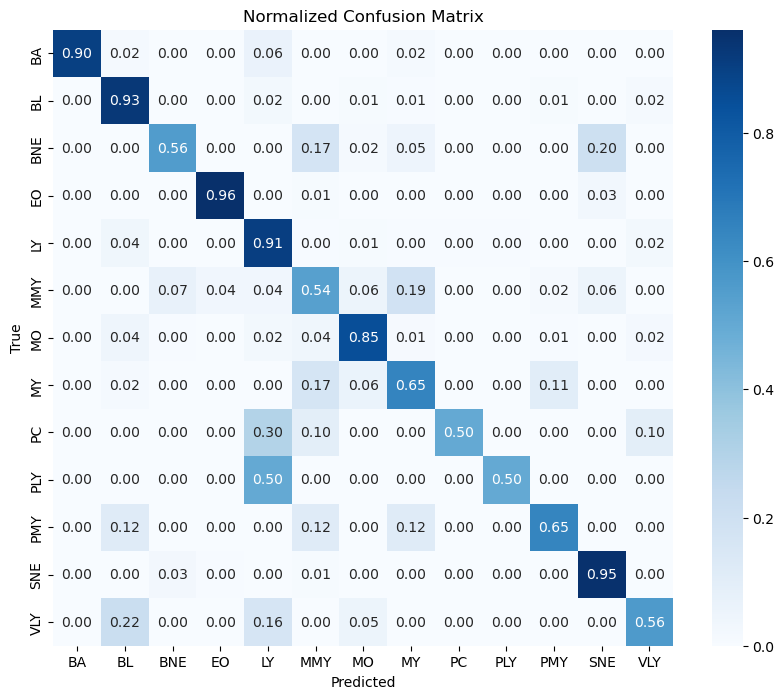

In [15]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig = plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=config.CLASS_NAMES,
            yticklabels=config.CLASS_NAMES)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

In [20]:
print(classification_report(all_labels, all_preds, target_names=config.CLASS_NAMES))

              precision    recall  f1-score   support

          BA       0.98      0.90      0.94        62
          BL       0.78      0.93      0.85       302
         BNE       0.35      0.56      0.43        59
          EO       0.92      0.96      0.94       129
          LY       0.97      0.91      0.94      1215
         MMY       0.32      0.54      0.40        54
          MO       0.92      0.85      0.88       412
          MY       0.57      0.65      0.61        66
          PC       0.50      0.50      0.50        10
         PLY       0.17      0.50      0.25         2
         PMY       0.42      0.65      0.51        17
         SNE       0.99      0.95      0.97      1953
         VLY       0.42      0.56      0.48        55

    accuracy                           0.91      4336
   macro avg       0.64      0.73      0.67      4336
weighted avg       0.93      0.91      0.91      4336

